In [3]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('england_all_cleaned.csv')

In [5]:
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA,Unnamed: 132
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40458,E3,02/05/2026,Harrogate,Barnet,1.0,2.0,A,1.0,1.0,D,...,2.80,3.7,2.30,NaN,NaN,NaN,2.70,3.60,2.40,NaN
40459,E3,02/05/2026,Notts County,Bristol Rvs,1.0,1.0,D,1.0,0.0,H,...,1.70,3.9,4.50,NaN,NaN,NaN,1.67,4.00,4.50,NaN
40460,E3,02/05/2026,Oldham,Accrington,3.0,0.0,H,1.0,0.0,H,...,1.85,3.7,3.90,NaN,NaN,NaN,1.91,3.75,3.70,NaN
40461,E3,02/05/2026,Swindon,Chesterfield,1.0,2.0,A,1.0,1.0,D,...,3.30,3.6,2.05,NaN,NaN,NaN,3.30,3.70,2.05,NaN


In [6]:
#רשימת העמודות החשובות 
keep_cols = [ 
    'Date', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',     # תוצאה סופית
    'HTHG', 'HTAG', 'HTR',     # מחצית
    'HS', 'AS',                # בעיטות
    'HST', 'AST',              # בעיטות למסגרת
    'HF', 'AF',                # עבירות
    'HC', 'AC',                # קרנות
    'HY', 'AY',                # צהובים
    'HR', 'AR',            # אדומים
]

# עכשיו מסננים רק את העמודות האלה
df = df[keep_cols]

In [7]:
df.shape

(40463, 21)

In [8]:
# מסיר שורות עם ערכים חסרים (NaN)
df = df.dropna()

In [9]:
# בדיקה אם יש משהו עדיין לא ריק
df.isna().any(axis=1).sum()

np.int64(0)

In [ ]:
שאלת המחקר 
לבדוק האם הקבוצה הביתית ניצחה או לא

In [10]:
# אם זה ניצחון ביתי אז 1 אם לא אז 0 
df['target'] = (df['FTHG'] > df['FTAG']).astype(int)   

In [11]:
# ===  הסרת עמודות שקשורות ישירות לתוצאה ===
columns_to_drop = ['FTR', 'FTHG', 'FTAG', 'HTHG', 'HTAG']
df = df.drop(columns=columns_to_drop, errors='ignore')

In [12]:
# === בחירת פיצ׳רים מספריים לחיזוי ===
features = [
    'HS','AS','HST','AST','HF','AF','HC','AC','HY','AY','HR','AR'
]
X = df[features]
y = df['target']

In [ ]:
 אחרי שעשיתי ניקוי דאטה והנדוס פיצרים עכשיו אני מוכן

In [13]:
# === חלוקת נתונים לאימון ובדיקה ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
y_train = y_train.reset_index(drop=True)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

In [ ]:
Logistic Regression עכשיו אני רוצה להתחיל לעשות על  

In [16]:
log_reg = LogisticRegression()   # המודל של רגרסיה לוגסטית 

In [17]:
# אימון המודל
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = log_reg.predict(X_test)          # 0 / 1
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]  # הסתברויות

In [19]:
acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_pred_prob)

print(f"Accuracy: {acc:.4f}")
print(f"Log Loss: {loss:.4f}")

Accuracy: 0.6963
Log Loss: 0.5803


In [ ]:
ברגרסיה לוגיסטית קיבלתי 0.6963 אחוז הצלחה 
עכשיו אני מנסה להגיע לאחוז הצלחה יותר גבוה מזה 

In [ ]:
עכשיו אני רוצה להתחיל עם מעט ניורונים כמו 100  
שכבה אחת

In [20]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(100, activation='relu'),    
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
) 

In [21]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [22]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6835 - loss: 0.6663 - val_accuracy: 0.6932 - val_loss: 0.5747
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6941 - loss: 0.6510 - val_accuracy: 0.6951 - val_loss: 0.5755
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6933 - loss: 0.6494 - val_accuracy: 0.6856 - val_loss: 0.5867
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6946 - loss: 0.6484 - val_accuracy: 0.6947 - val_loss: 0.5800
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6955 - loss: 0.6475 - val_accuracy: 0.6885 - val_loss: 0.5838
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6947 - loss: 0.6473 - val_accuracy: 0.6894 - val_loss: 0.5808
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6939 - loss: 0.6470 - val_accuracy: 0.6878 - val_loss: 0.5834
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6938 - loss: 0.6459 - 

In [23]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5747
 Test Accuracy: 0.6932


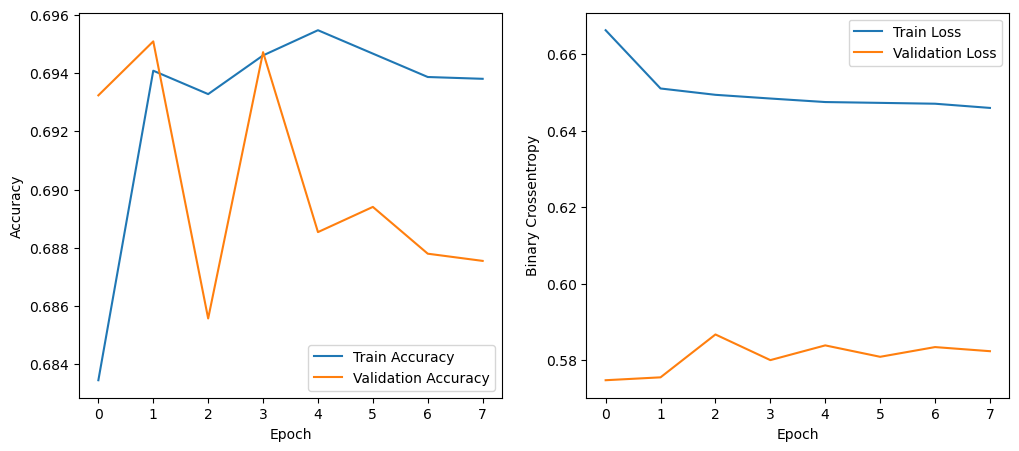

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show() 

In [ ]:
Test Accuracy: 0.6932   
בגרף הזה אין פה אוברפיטנג  
Accuracy כי אין פער גדול בין שני הקווים המספרים קרובים אחד לשני ב
עכשיו אני רוצה להעלות את מספר הניורונים ל(400) כדי להגיע לאחוז הצלחה גדול יותר 

In [25]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(400, activation='relu'), 
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)   

In [26]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [27]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6898 - loss: 0.6589 - val_accuracy: 0.6934 - val_loss: 0.5808
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6918 - loss: 0.6514 - val_accuracy: 0.6890 - val_loss: 0.5841
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6920 - loss: 0.6498 - val_accuracy: 0.6877 - val_loss: 0.5857
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6946 - loss: 0.6489 - val_accuracy: 0.6920 - val_loss: 0.5748
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6929 - loss: 0.6486 - val_accuracy: 0.6816 - val_loss: 0.5900
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6943 - loss: 0.6471 - val_accuracy: 0.6921 - val_loss: 0.5781
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6941 - loss: 0.6468 - val_accuracy: 0.6961 - val_loss: 0.5733
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6943 - loss: 0.6459 - 

In [28]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5733
 Test Accuracy: 0.6961


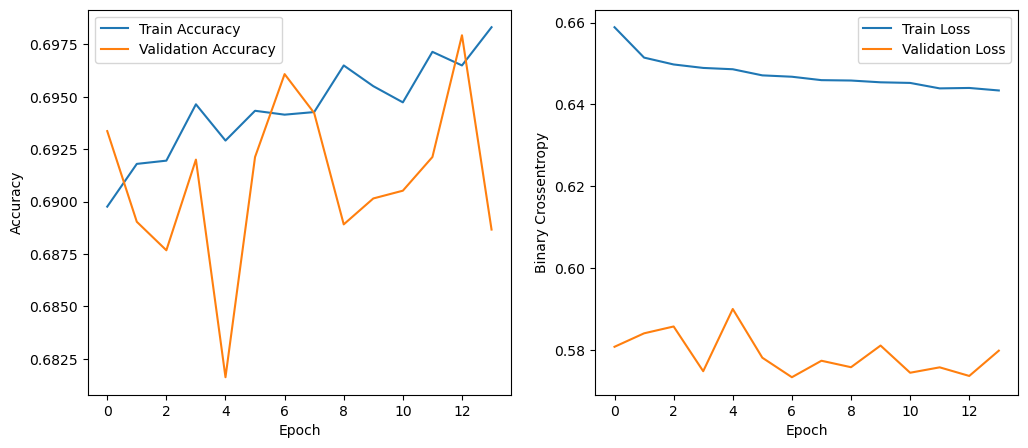

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6961    
בגרף הזה אין פה אוברפיטנג
עכשיו אחרי שהעליתי את מספר הניורוים ל 400 קיבלתי ציון קצת גבוה מקודם אבל בסוף אותו דבר עדיין 
אני רוצה להעלות את מספר הניורונים ל 1000

In [30]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(1000, activation='relu'),    
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  

In [31]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [32]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6873 - loss: 0.6612 - val_accuracy: 0.6899 - val_loss: 0.5825
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6914 - loss: 0.6520 - val_accuracy: 0.6893 - val_loss: 0.5834
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6931 - loss: 0.6508 - val_accuracy: 0.6925 - val_loss: 0.5759
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6929 - loss: 0.6498 - val_accuracy: 0.6883 - val_loss: 0.5796
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6933 - loss: 0.6491 - val_accuracy: 0.6882 - val_loss: 0.5826
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6947 - loss: 0.6478 - val_accuracy: 0.6958 - val_loss: 0.5741
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6953 - loss: 0.6473 - val_accuracy: 0.6951 - val_loss: 0.5727
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6948 - loss: 0.6468 - 

In [33]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5727
 Test Accuracy: 0.6951


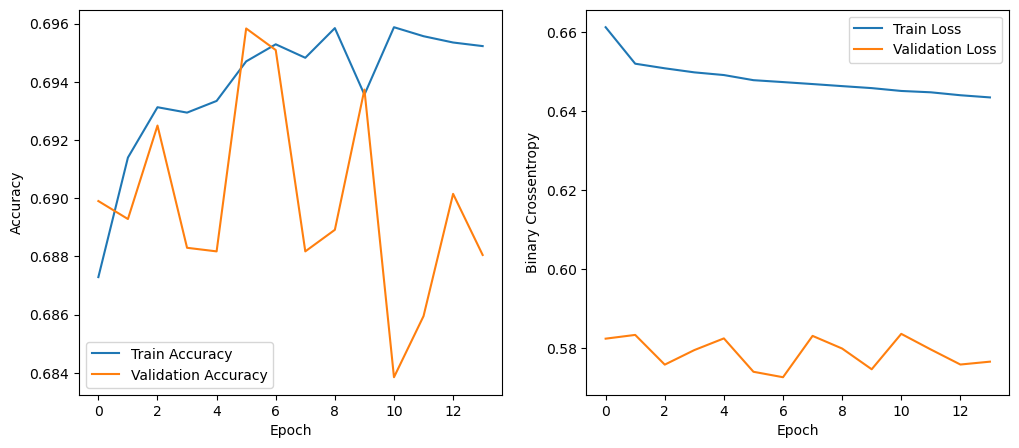

In [34]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6951   
בגרף הזה אין אוברפיטנג 
עכשיו עם 1000 ניורונים קיבלתי ציון קרוב ממה שיצא לי קודם עם 400 ניורונים   
עכשיו אני רוצה להעלות את הניורונים עוד כדי להגיע למקסימום אחוז הצלחה

In [35]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(2000, activation='relu'),    
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  

In [36]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [37]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6865 - loss: 0.6617 - val_accuracy: 0.6930 - val_loss: 0.5776
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6908 - loss: 0.6535 - val_accuracy: 0.6932 - val_loss: 0.5794
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6912 - loss: 0.6515 - val_accuracy: 0.6845 - val_loss: 0.5843
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6930 - loss: 0.6509 - val_accuracy: 0.6930 - val_loss: 0.5782
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6922 - loss: 0.6499 - val_accuracy: 0.6932 - val_loss: 0.5744
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6937 - loss: 0.6490 - val_accuracy: 0.6946 - val_loss: 0.5764
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6932 - loss: 0.6481 - val_accuracy: 0.6927 - val_loss: 0.5780
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6943 - loss: 0.6475 - 

In [38]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5724
 Test Accuracy: 0.6925


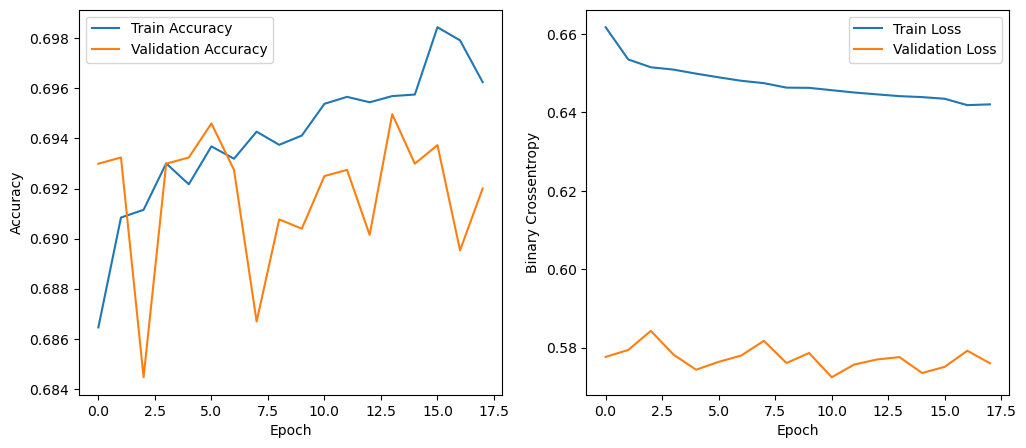

In [39]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6925
גם פה אין אוברפיטנג
אחרי שהעליתי ל 2000 ניורונים שזה מספר גבוה, קיבלתי ציון אותו מה שיצא לי קודם בהמודלים הקודמים       
עכשיו אני רוצה לנסות עם שתי שכבות חבויות 

In [41]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(200, activation='relu'), 
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)   

In [42]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [43]:
# ===  אימון המודל ===

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6851 - loss: 0.6624 - val_accuracy: 0.6876 - val_loss: 0.5791
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6903 - loss: 0.6519 - val_accuracy: 0.6892 - val_loss: 0.5783
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6923 - loss: 0.6489 - val_accuracy: 0.6911 - val_loss: 0.5725
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6944 - loss: 0.6482 - val_accuracy: 0.6950 - val_loss: 0.5729
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6965 - loss: 0.6463 - val_accuracy: 0.6948 - val_loss: 0.5755
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6981 - loss: 0.6444 - val_accuracy: 0.6877 - val_loss: 0.5847
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6968 - loss: 0.6432 - val_accuracy: 0.6843 - val_loss: 0.5849
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6971 - loss: 0.6419 -

In [44]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5725
 Test Accuracy: 0.6911


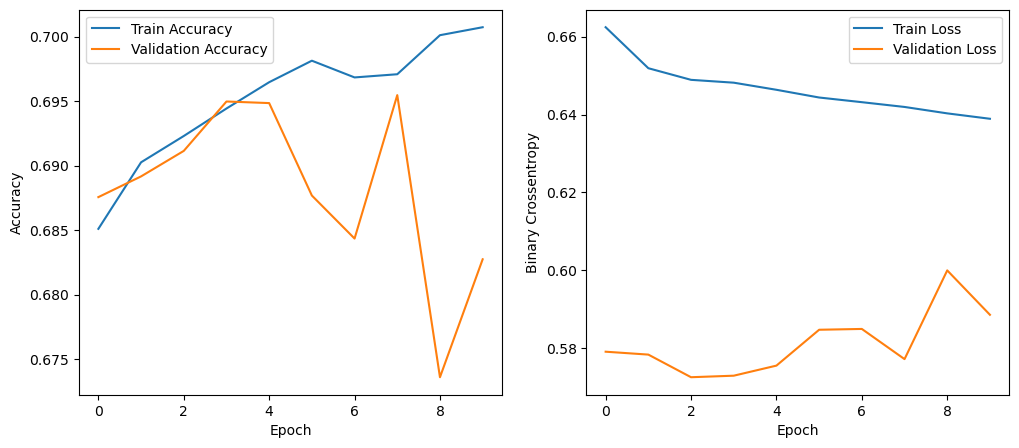

In [45]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
 Test Accuracy: 0.6911
לא נראה שיש אוברפיטנג   
עם שתי שכבות לא הגעתי ליעד 
עכשיו אני רוצה להעלות את מספר הניורונים עם השתי השכבות

In [47]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(500, activation='relu'), 
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)   

In [48]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [49]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6840 - loss: 0.6620 - val_accuracy: 0.6817 - val_loss: 0.5875
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6893 - loss: 0.6526 - val_accuracy: 0.6842 - val_loss: 0.5896
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6936 - loss: 0.6502 - val_accuracy: 0.6908 - val_loss: 0.5815
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6929 - loss: 0.6487 - val_accuracy: 0.6972 - val_loss: 0.5720
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6948 - loss: 0.6473 - val_accuracy: 0.6898 - val_loss: 0.5802
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6943 - loss: 0.6463 - val_accuracy: 0.6898 - val_loss: 0.5842
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6957 - loss: 0.6451 - val_accuracy: 0.6923 - val_loss: 0.5858
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6972 - loss: 0.6432 -

In [50]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5720
 Test Accuracy: 0.6972


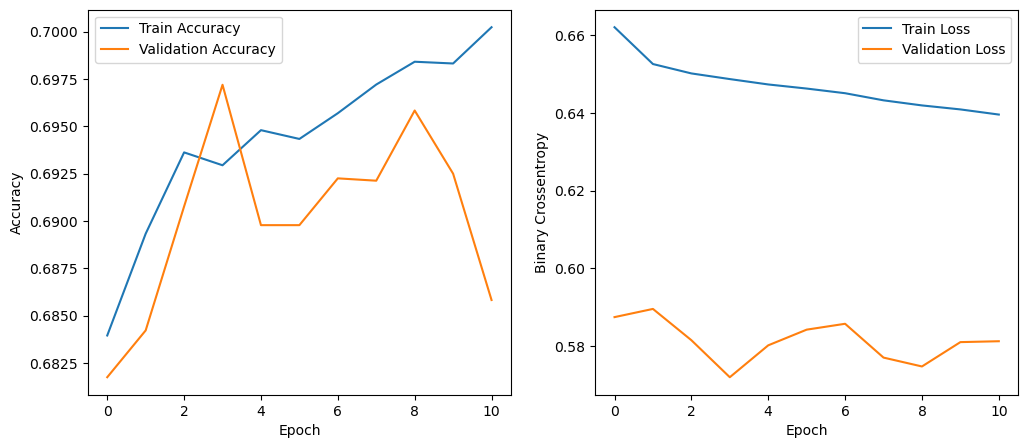

In [51]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6972
אין אוברפיטנג
עם שתי שכבות ואחרי שהעליתי את מספר הניורונים ל 500 קיבלתי ציון קרוב ממה שקיבלתי גם קודם 
עכשיו אני רוצה להעלות את הניורונים ל1000 עם שתי השכבות

In [52]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(1000, activation='relu'), 
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  

In [53]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [54]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6833 - loss: 0.6622 - val_accuracy: 0.6931 - val_loss: 0.5785
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6892 - loss: 0.6527 - val_accuracy: 0.6908 - val_loss: 0.5796
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6914 - loss: 0.6517 - val_accuracy: 0.6913 - val_loss: 0.5774
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6933 - loss: 0.6496 - val_accuracy: 0.6911 - val_loss: 0.5795
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6957 - loss: 0.6478 - val_accuracy: 0.6934 - val_loss: 0.5744
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6936 - loss: 0.6473 - val_accuracy: 0.6900 - val_loss: 0.5828
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6956 - loss: 0.6461 - val_accuracy: 0.6904 - val_loss: 0.5786
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6962 - loss: 0.6452 -

In [56]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5744
 Test Accuracy: 0.6934


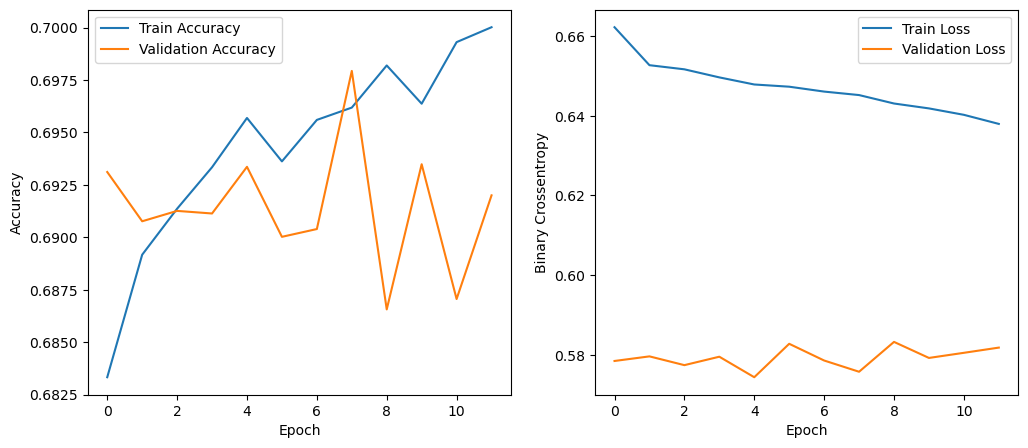

In [57]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6934
אין פה אוברפיטנג 
אחרי שהעליתי 1000 ניורונים יצא לי כמו הקודם  
עכשיו אני רוצה להעלות ל2000

In [58]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(2000, activation='relu'), 
    layers.Dense(200, activation='relu'),
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  

In [59]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [60]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6848 - loss: 0.6626 - val_accuracy: 0.6901 - val_loss: 0.5838
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6901 - loss: 0.6541 - val_accuracy: 0.6815 - val_loss: 0.5897
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6934 - loss: 0.6517 - val_accuracy: 0.6916 - val_loss: 0.5772
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6937 - loss: 0.6504 - val_accuracy: 0.6921 - val_loss: 0.5746
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6923 - loss: 0.6496 - val_accuracy: 0.6960 - val_loss: 0.5728
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6964 - loss: 0.6482 - val_accuracy: 0.6908 - val_loss: 0.5815
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6969 - loss: 0.6477 - val_accuracy: 0.6900 - val_loss: 0.5803
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6972 -

In [61]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5728
 Test Accuracy: 0.6960


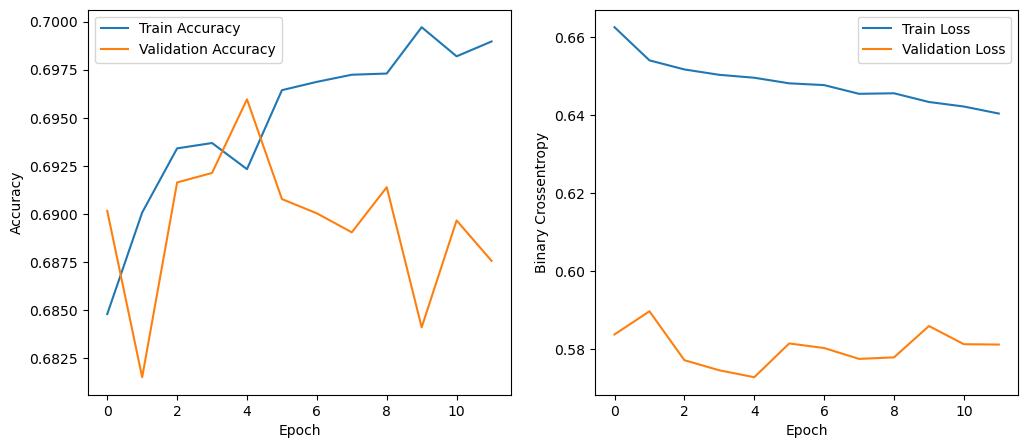

In [62]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6960
גם פה אין אוברפיטנג
אחרי שהעליתי ל 2000 עוד לא הגעתי לציון גבוה קיבלתי כמעט אותו ציון ממה שיצא קודם
dropout עכשיו אני רוצה לנסות עם 

In [63]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(100, activation='relu'),   
    layers.Dropout(0.3), 
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [65]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6726 - loss: 0.6764 - val_accuracy: 0.6929 - val_loss: 0.5799
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6890 - loss: 0.6591 - val_accuracy: 0.6904 - val_loss: 0.5802
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6921 - loss: 0.6542 - val_accuracy: 0.6903 - val_loss: 0.5789
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6889 - loss: 0.6539 - val_accuracy: 0.6910 - val_loss: 0.5784
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6895 - loss: 0.6537 - val_accuracy: 0.6931 - val_loss: 0.5764
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6920 - loss: 0.6520 - val_accuracy: 0.6932 - val_loss: 0.5791
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6920 - loss: 0.6513 - val_accuracy: 0.6941 - val_loss: 0.5743
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6923 - loss: 0.6505 - 

In [66]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5737
 Test Accuracy: 0.6925


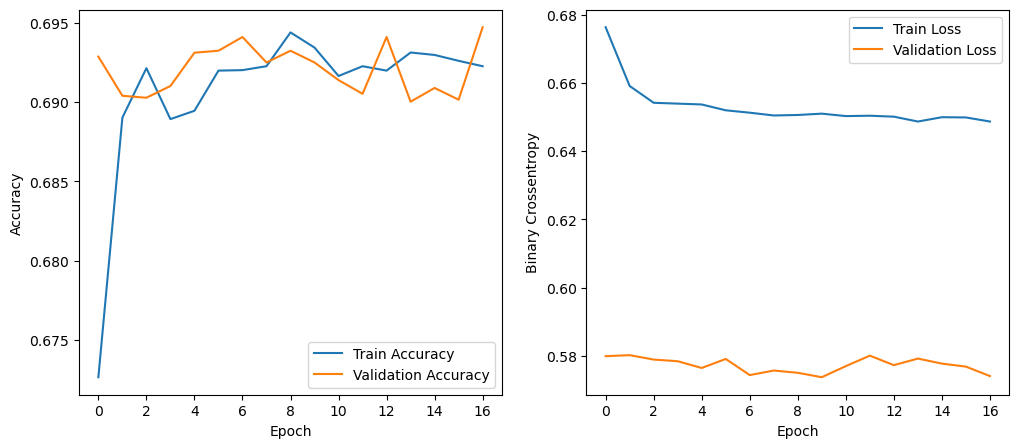

In [67]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6925
זה נראה שהשני הקווים קרובים אחד לשני אין אוברפיטנג
עוד לא השתפר קיבלתי ציון דומה ממה שקיבלתי קודם
dropout עכשיו אני מעלה את מספר הניורונים ל 500

In [68]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(500, activation='relu'),   
    layers.Dropout(0.3),  
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
) 

In [70]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [71]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6833 - loss: 0.6630 - val_accuracy: 0.6952 - val_loss: 0.5761
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6892 - loss: 0.6540 - val_accuracy: 0.6905 - val_loss: 0.5802
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6909 - loss: 0.6524 - val_accuracy: 0.6805 - val_loss: 0.5887
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6927 - loss: 0.6513 - val_accuracy: 0.6888 - val_loss: 0.5877
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6905 - loss: 0.6513 - val_accuracy: 0.6937 - val_loss: 0.5754
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6924 - loss: 0.6494 - val_accuracy: 0.6939 - val_loss: 0.5737
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6935 - loss: 0.6497 - val_accuracy: 0.6940 - val_loss: 0.5734
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6918 - loss: 0.6498 - 

In [72]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5734
 Test Accuracy: 0.6940


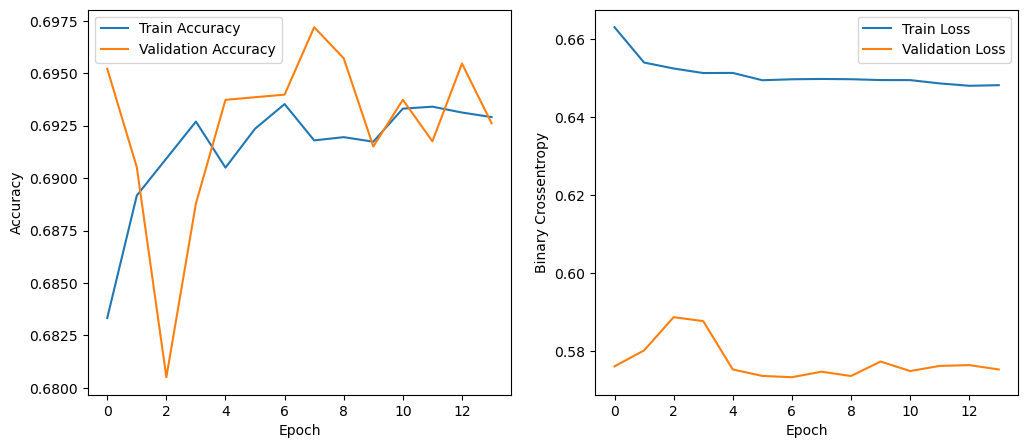

In [73]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()

In [ ]:
Test Accuracy: 0.6940
אין אוברפיטנג
גם עם 500 ניורונים לא קיבלתי את הציון המקסימלי יצא לי כמו במודלים הקודמים

In [74]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(1000, activation='relu'),   
    layers.Dropout(0.3),  
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
) 

In [75]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [76]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6851 - loss: 0.6621 - val_accuracy: 0.6953 - val_loss: 0.5715
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6893 - loss: 0.6543 - val_accuracy: 0.6916 - val_loss: 0.5801
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6904 - loss: 0.6524 - val_accuracy: 0.6916 - val_loss: 0.5791
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6922 - loss: 0.6517 - val_accuracy: 0.6880 - val_loss: 0.5811
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6913 - loss: 0.6515 - val_accuracy: 0.6894 - val_loss: 0.5776
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6916 - loss: 0.6511 - val_accuracy: 0.6939 - val_loss: 0.5747
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6924 - loss: 0.6504 - val_accuracy: 0.6878 - val_loss: 0.5814
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6911 - loss: 0.6499 -

In [77]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5715
 Test Accuracy: 0.6953


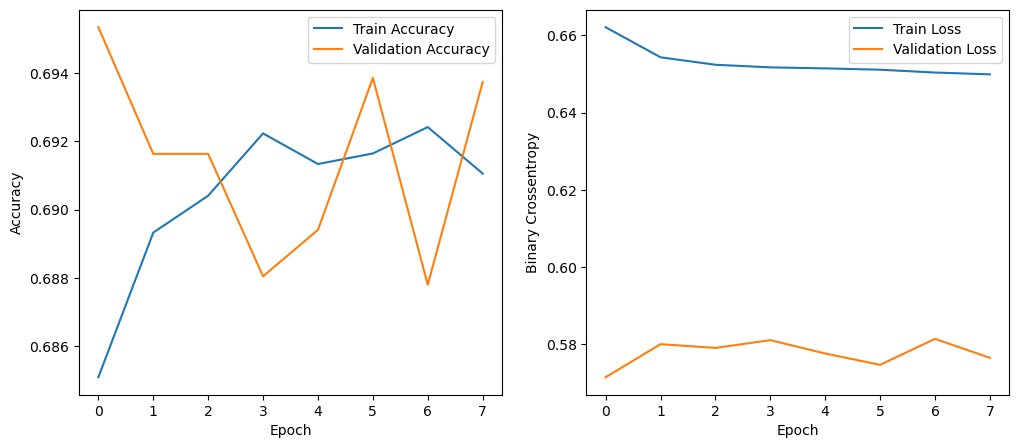

In [78]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show() 

In [ ]:
Test Accuracy: 0.6953
אין אוברפיטנג
עם 1000 ניורונים ו דרובאווט יצא דומה לתוצאות הקודמות כלומר לא השתפר

In [79]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # מספר הפיצ׳רים
    layers.Dense(1000, activation='relu'),   
    layers.Dropout(0.3), 
    layers.Dense(100, activation='relu'), 
    layers.Dense(1, activation='sigmoid')    
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
) 

In [80]:
# ===  חישוב משקלי מחלקות (כדי לאזן בין תוצאות) ===
class_distribution = y_train.value_counts()
class_weights = {0: 1, 1: class_distribution[0] / class_distribution[1]}

In [81]:
# ===  אימון המודל ===
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6843 - loss: 0.6629 - val_accuracy: 0.6946 - val_loss: 0.5745
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6883 - loss: 0.6547 - val_accuracy: 0.6846 - val_loss: 0.5847
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6935 - loss: 0.6518 - val_accuracy: 0.6847 - val_loss: 0.5815
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6926 - loss: 0.6512 - val_accuracy: 0.6903 - val_loss: 0.5773
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6937 - loss: 0.6507 - val_accuracy: 0.6899 - val_loss: 0.5762
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6938 - loss: 0.6490 - val_accuracy: 0.6916 - val_loss: 0.5781
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6947 - loss: 0.6482 - val_accuracy: 0.6931 - val_loss: 0.5783
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6953 - loss: 0.6476 -

In [82]:
# ===  הערכת ביצועים ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")

 Test Loss: 0.5745
 Test Accuracy: 0.6946


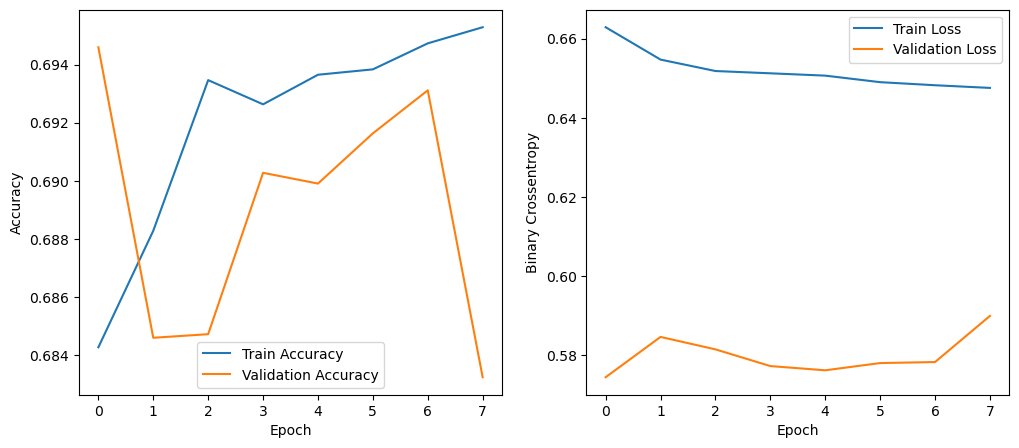

In [83]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.show()  


In [ ]:
Test Accuracy: 0.6946  
בגרף אין אוברפיטינג 
גם פה יצא אותו דבר לא השתפר

In [ ]:
מסקנה כללית 
קיבלתי אותה תוצאה בכל המודלים   
הרגרסיה לוגיסטית הגיעה לאותה תוצאה של כל המודלים שעשיתי אותם  
לאחר שהגדלתי את מספר הנוירונים, הוספתי שכבה נוספת לרשת הנוירונים והוספתי דרובאווט
ובכל המקרים קיבלתי אותו ציון 69% אין שיפור